In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/Fraud Detection Dataset.csv")

In [4]:
df

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


In [5]:
df.shape

(51000, 12)

In [15]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

In [16]:
df.describe

<bound method NDFrame.describe of       Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
0                 T1     4174             1292.76   ATM Withdrawal   
1                 T2     4507             1554.58   ATM Withdrawal   
2                 T3     1860             2395.02   ATM Withdrawal   
3                 T4     2294              100.10     Bill Payment   
4                 T5     2130             1490.50      POS Payment   
...              ...      ...                 ...              ...   
50995         T33982     2339             3112.51     Bill Payment   
50996         T31261     2152             2897.15  Online Purchase   
50997         T12293     3345             2204.43      POS Payment   
50998         T42287     1518             4787.17      POS Payment   
50999         T13665     2315              814.72      POS Payment   

       Time_of_Transaction Device_Used       Location  \
0                     16.0      Tablet  San Francisco   
1                     13.0      Mobile       New York   
2                      NaN      Mobile            NaN   
3                     15.0     Desktop        Chicago   
4                     19.0      Mobile  San Francisco   
...                    ...         ...            ...   
50995                 15.0      Mobile       New York   
50996                  3.0      Mobile          Miami   
50997                 18.0      Mobile  San Francisco   
50998                 19.0      Tablet       New York   
50999                  3.0      Tablet    Los Angeles   

       Previous_Fraudulent_Transactions  Account_Age  \
0                                     0          119   
1                                     4           79   
2                                     3          115   
3                                     4            3   
4                                     2           57   
...                                 ...          ...   
50995                                 0            7   
50996                                 1           75   
50997                                 3           73   
50998                                 2          108   
50999                                 0           50   

       Number_of_Transactions_Last_24H  Payment_Method  Fraudulent  
0                                   13      Debit Card           0  
1                                    3     Credit Card           0  
2                                    9             NaN           0  
3                                    4             UPI           0  
4                                    7     Credit Card           0  
...                                ...             ...         ...  
50995                                8      Debit Card           0  
50996                               11     Net Banking           1  
50997                                5     Credit Card           0  
50998                               14     Net Banking           0  
50999                               10  Invalid Method           0  

[51000 rows x 12 columns]>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 non-null  int64  
dtypes: f

In [18]:
df['Transaction_Type'].nunique()

5

In [7]:
df['Transaction_Type'].unique()

array(['ATM Withdrawal', 'Bill Payment', 'POS Payment', 'Bank Transfer',
       'Online Purchase'], dtype=object)

In [22]:
df['Transaction_Amount'].sum()

np.float64(145258189.55)

In [23]:
df['Transaction_Amount'].mean()

np.float64(2996.249784447195)

BAR CHART

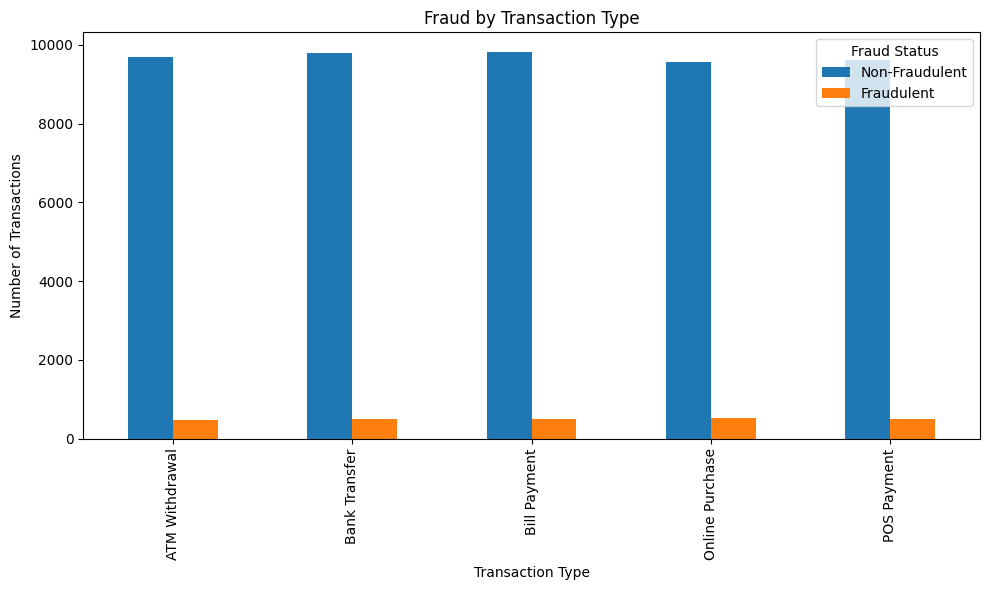

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

grouped = df.groupby(['Transaction_Type', 'Fraudulent']).size().unstack(fill_value=0)

grouped.columns = ['Non-Fraudulent', 'Fraudulent']

grouped.plot(
    kind='bar',
    figsize=(10, 6),
    title='Fraud by Transaction Type'
)

plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.legend(title='Fraud Status')

plt.tight_layout()
plt.show()

PIE CHART

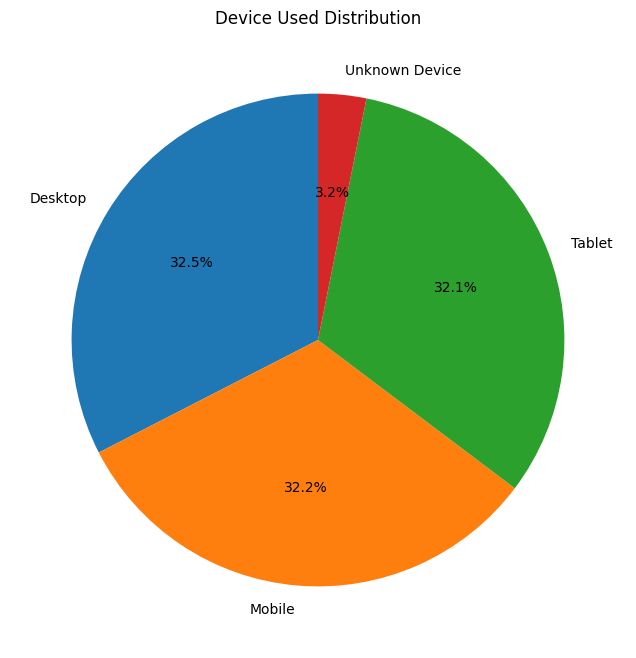

In [9]:
import matplotlib.pyplot as plt

device_counts = df['Device_Used'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    device_counts,
    labels=device_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Device Used Distribution')
plt.show()

LINE CHART

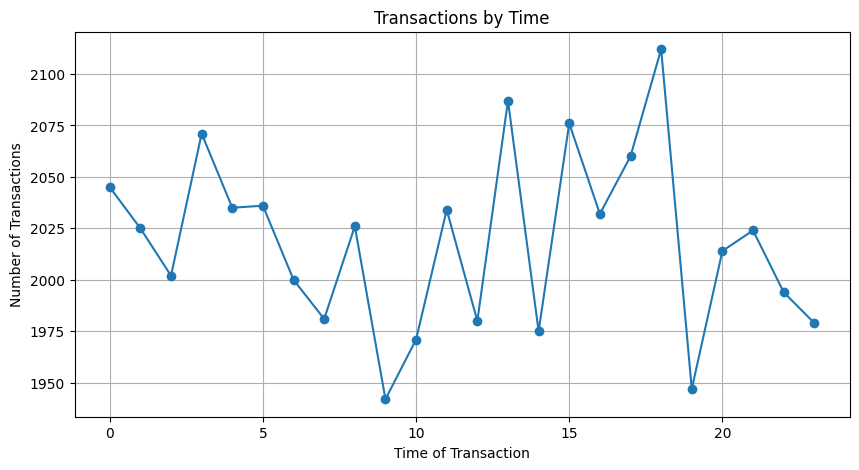

In [12]:
import matplotlib.pyplot as plt

# Count transactions by transaction time
time_counts = df['Time_of_Transaction'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(time_counts.index, time_counts.values, marker='o')
plt.title('Transactions by Time')
plt.xlabel('Time of Transaction')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

DONUT CHART

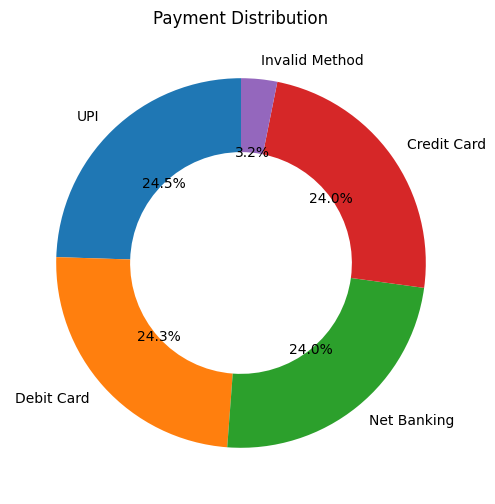

In [11]:
import matplotlib.pyplot as plt

payment_counts = df['Payment_Method'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.4}
)
plt.title('Payment Distribution')
plt.show()

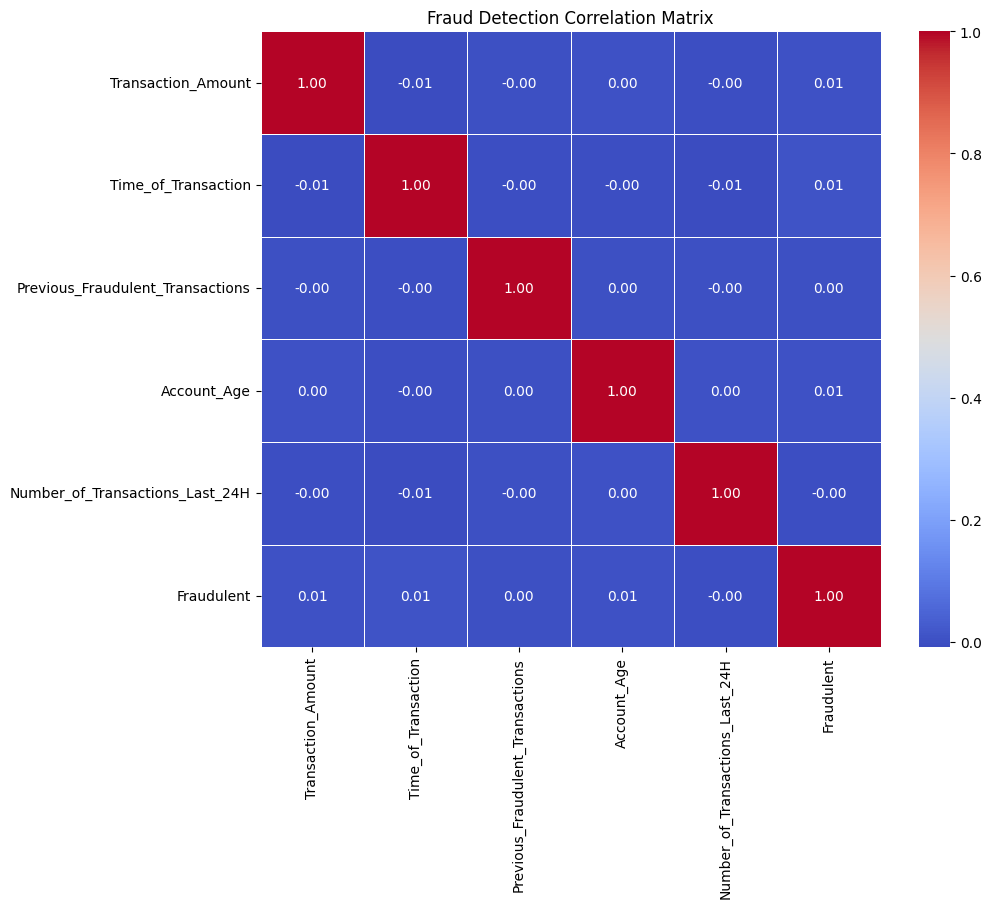

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric columns
corr_matrix = df[
    [
        'Transaction_Amount',
        'Time_of_Transaction',
        'Previous_Fraudulent_Transactions',
        'Account_Age',
        'Number_of_Transactions_Last_24H',
        'Fraudulent'
    ]
].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,

    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Fraud Detection Correlation Matrix')
plt.show()

In [ ]:
SCATTER PLOT

/tmp/ipykernel_663/2986183292.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Fraudulent')


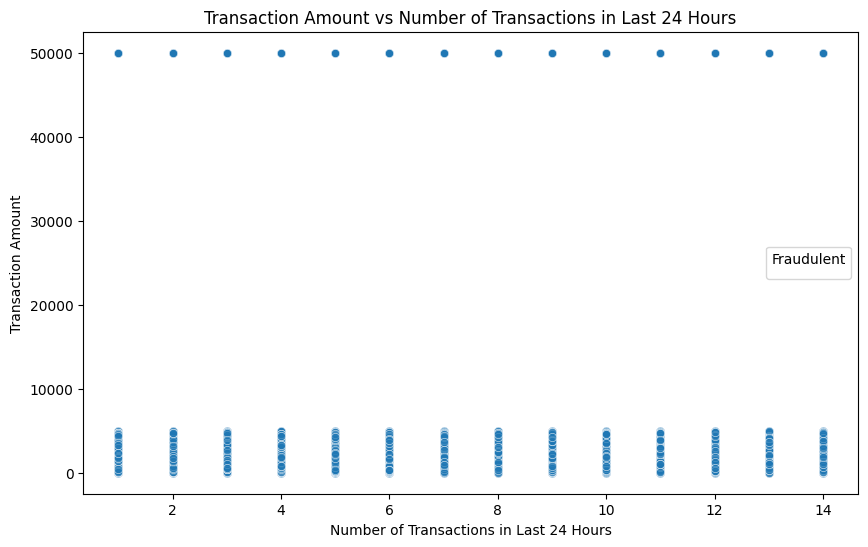

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Number_of_Transactions_Last_24H',
    y='Transaction_Amount',
    alpha=0.7
)

plt.title('Transaction Amount vs Number of Transactions in Last 24 Hours')
plt.xlabel('Number of Transactions in Last 24 Hours')
plt.ylabel('Transaction Amount')
plt.legend(title='Fraudulent')
plt.show()